Здесь попробую простые линейные модели

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
import kagglehub
import os

data_path = kagglehub.competition_download('playground-series-s6e1')

100%|██████████| 13.8M/13.8M [00:00<00:00, 83.3MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
np.random.seed(33)

# Основной код

In [ ]:
train_data = pd.read_csv(data_path + '/train.csv')
test_data = pd.read_csv(data_path + '/test.csv')

In [ ]:
def preprocess_data(data):
    data= data.replace({
        # ordinal encoding
        'sleep_quality': {
            'poor': 1,
            'average': 2,
            'good': 3
        },
        'facility_rating': {
            'low': 1,
            'medium': 2,
            'high': 3,
        },
        'course': {
            'diploma': 1,
            'ba': 2,
            'b.com': 3,
            'bba': 4,
            'bca': 5,
            'b.sc': 6,
            'b.tech': 7
        },
        'exam_difficulty': {
            'easy': 1,
            'moderate': 2,
            'hard': 3
        },

        # binary encoding
        'internet_access': {
            'no': 0,
            'yes': 1,
        }
    })

    data = pd.get_dummies(data, columns=['gender', 'study_method'], prefix=['gender', 'method'], dtype=int, drop_first=True)
    return data



train_data = preprocess_data(train_data)
test_data = preprocess_data(test_data)

/tmp/ipython-input-4140179311.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data= data.replace({
/tmp/ipython-input-4140179311.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data= data.replace({


In [ ]:
train_data.columns

Index(['id', 'age', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'facility_rating',
       'exam_difficulty', 'exam_score', 'gender_male', 'gender_other',
       'method_group study', 'method_mixed', 'method_online videos',
       'method_self-study'],
      dtype='object')

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDRegressor

X = train_data.drop(columns=['id', 'exam_score']).to_numpy()
y = train_data['exam_score'].to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
model = SGDRegressor(
    loss='huber',
    early_stopping=False,
    verbose=0,
    random_state=33,
)

scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')

In [ ]:
scores

array([-8.88961027, -8.91330091, -8.88479583, -8.91017185, -8.8983359 ])

# Выводы и гипотезы

# Поток

In [ ]:
from scipy import sparse
import seaborn as sns

<Axes: >

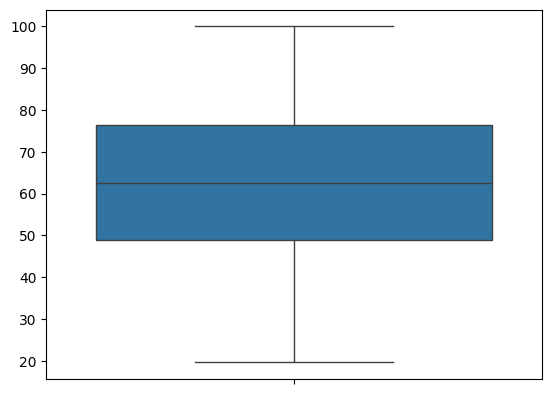

In [ ]:
sns.boxplot(y=y)

In [ ]:
print(np.linalg.det(X_train.T @ X_train))
print(sparse.issparse(X_train))
print(np.linalg.cond(X_train))

1.2643956777122e+85
False
2.406656514266218
